# Week 3: Sobel-Based Gradient Extraction

This week, we have extracted gradient information from cropped vehicle image using the Sobel operator.

## 1. Grayscale Conversion

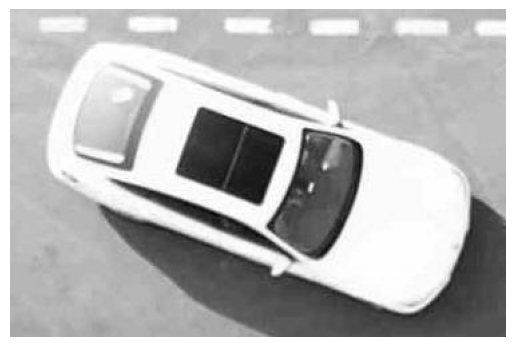

In [ ]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("v1_Sedan_17.1deg.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

## 2. Sobel X and Sobel Y

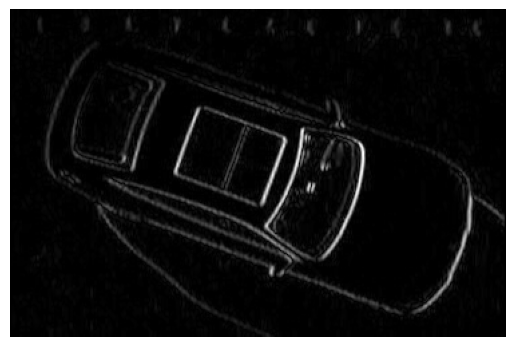

In [ ]:
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
plt.imshow(abs(sobel_x), cmap="gray")
plt.axis("off")
plt.show()

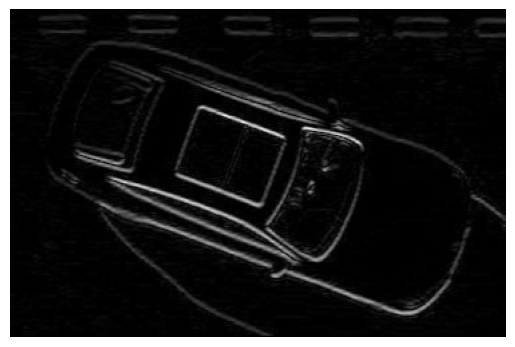

In [ ]:
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
plt.imshow(abs(sobel_y), cmap="gray")
plt.axis("off")
plt.show()

## 3. Gradient Magnitude

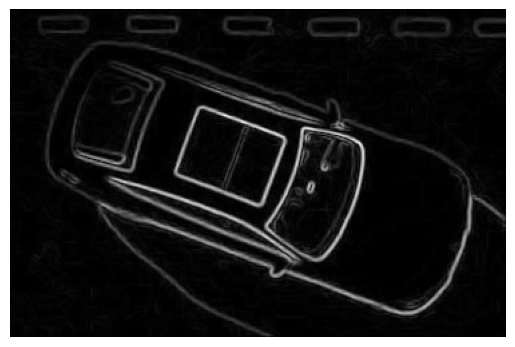

In [ ]:
import numpy as np
gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
gradient_magnitude = np.uint8(
    255 * gradient_magnitude / gradient_magnitude.max()
)
plt.imshow(gradient_magnitude, cmap="gray")
plt.axis("off")
plt.show()

## 4. Dominant Gradient Direction

In [ ]:
gradient_direction = np.degrees(np.arctan2(sobel_y, sobel_x))
angles = gradient_direction.flatten()
magnitudes = gradient_magnitude.flatten()
hist, bins = np.histogram(
    angles,
    bins=180,
    range=(-90, 90),
    weights=magnitudes
)
dominant_angle = bins[np.argmax(hist)]
print("Dominant gradient direction:", dominant_angle, "degrees")

Dominant gradient direction: 11.0 degrees
